# Learning curves i dataanalyse

En learning curve viser hvordan feilen endrer seg når modellen får mer data eller øker i kompleksitet.

- Training error: feilen på de dataene modellen faktisk trenes på. Denne faller vanligvis når modellen får mer informasjon eller blir mer fleksibel.
- Cross-validation error: feilen på data som modellen ikke har sett under trening. Denne er viktig for å se om modellen generaliserer, ikke bare memoriserer treningsdata.

Typisk ser vi at train error synker med mer data eller flere komponenter, mens CV error først synker og deretter flater ut eller stiger hvis modellen begynner å overfitte.

Nedenfor er noen illustrative eksempler på slike kurver.


## PLS-modell for diabetes-datasettet

Nå bruker vi `sklearn`-datasettet `diabetes` for å gjøre en liten PLS-analyse.

Vi deler dataene i en treningsmengde (80 %) og en testmengde (20 %). Deretter fitter vi PLS-modeller med 1 til 10 komponenter, og sammenligner treningsfeil, kryssvalideringsfeil og testfeil for å lage en kompleksitetskurve.


In [ ]:
from sklearn import datasets
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml

# data = fetch_openml(data_id=505, as_frame=False)
X, y = data.data, data.target.astype(float)
# X: (215, 100), y: fat content



# Del data i trenings- og testmengde (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

n_components = range(1, 5)
train_rmse = []
cv_rmse = []
test_rmse = []

for n in n_components:
    pls = PLSRegression(n_components=n)

    # Tren på treningsdata
    pls.fit(X_train, y_train)
    y_train_pred = pls.predict(X_train)
    train_rmse.append(np.sqrt(mean_squared_error(y_train, y_train_pred)))

    # Kryssvalidering på treningsdata
    scores = cross_val_score(
        pls,
        X_train,
        y_train,
        cv=5,
        scoring='neg_root_mean_squared_error',
        n_jobs=None,
    )
    cv_rmse.append(-scores.mean())

    # Test-feil på de 20 % som aldri ble brukt i modellbygging
    y_test_pred = pls.predict(X_test)
    test_rmse.append(np.sqrt(mean_squared_error(y_test, y_test_pred)))

# Plot kompleksitetskurve
plt.figure(figsize=(4, 3))
plt.plot(list(n_components), train_rmse, marker='o', linewidth=2, label='Training RMSE')
plt.plot(list(n_components), cv_rmse, marker='o', linewidth=2, label='CV RMSE')
plt.plot(list(n_components), test_rmse, marker='o', linewidth=2, label='Prediction RMSE (test)')

plt.xlabel('Number of PLS components')
plt.ylabel('RMSE')
plt.title('PLS complexity curve for meat samples data')
plt.xticks(list(n_components))
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

# Vis de beste komponentene i tabellform
results = list(zip(list(n_components), train_rmse, cv_rmse, test_rmse))
print('n_components | train_rmse | cv_rmse | test_rmse')
for row in results:
    print(f'{row[0]:>12} | {row[1]:>10.4f} | {row[2]:>8.4f} | {row[3]:>8.4f}')


ValueError: md5 checksum of local file for https://openml.org/data/v1/download/52617/tecator.arff does not match description: expected: bc1cfff2d40bc7e47e7b6aa0826f3d5d but got 87899c4863968a25a3dcd6f241ee91c3. Downloaded file could have been modified / corrupted, clean cache and retry...

In [ ]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Hent OpenML-datasettet
# Dette er datasettet "meat" med mål på fettinnhold
# (similar to the spectroscopy example)
data = fetch_openml(data_id=505, as_frame=False)
X, y = data.data, data.target.astype(float)

# Definer prosentandelene av data som skal brukes
fractions = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 1.00]
rng = np.random.RandomState(42)
train_rmse = []
cv_rmse = []
pred_rmse = []
obs_used = []

for frac in fractions:
    n_samples = max(1, int(round(len(X) * frac)))
    idx = rng.choice(len(X), size=n_samples, replace=False)
    X_sub = X[idx]
    y_sub = y[idx]

    # Del inn i trenings- og testmengde (80/20) for hver delmengde
    X_train, X_test, y_train, y_test = train_test_split(
        X_sub,
        y_sub,
        test_size=0.2,
        random_state=42,
    )

    pls = PLSRegression(n_components=1)

    # Treningsfeil
    pls.fit(X_train, y_train)
    y_train_pred = pls.predict(X_train)
    train_rmse.append(np.sqrt(mean_squared_error(y_train, y_train_pred)))

    # Kryssvalidering på treningsdata
    cv_scores = cross_val_score(
        pls,
        X_train,
        y_train,
        cv=5,
        scoring='neg_root_mean_squared_error',
        n_jobs=None,
    )
    cv_rmse.append(-cv_scores.mean())

    # Modell brukes på testdata
    y_pred = pls.predict(X_test)
    pred_rmse.append(np.sqrt(mean_squared_error(y_test, y_pred)))
    obs_used.append(len(X_train))

# Plot learning curve: error vs. antall observasjoner i treningsdata
plt.figure(figsize=(4, 3))
plt.plot(obs_used, train_rmse, marker='o', linewidth=2, color='tab:green', label='Training')
plt.plot(obs_used, cv_rmse, marker='o', linewidth=2, color='tab:blue', label='CV')
plt.plot(obs_used, pred_rmse, marker='o', linewidth=2, color='tab:red', label='Prediction(test)')
plt.xlabel('Training observations used')
plt.ylabel('RMSE')
plt.title('PLSR learning curve for OpenML meat data')
plt.xticks(obs_used)
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

print('n_train | train_rmse | cv_rmse | pred_rmse')
for n, tr_err, cv_err, pred_err in zip(obs_used, train_rmse, cv_rmse, pred_rmse):
    print(f'{n:>7} | {tr_err:>10.4f} | {cv_err:>8.4f} | {pred_err:>10.4f}')

ValueError: md5 checksum of local file for https://openml.org/data/v1/download/52617/tecator.arff does not match description: expected: bc1cfff2d40bc7e47e7b6aa0826f3d5d but got 87899c4863968a25a3dcd6f241ee91c3. Downloaded file could have been modified / corrupted, clean cache and retry...

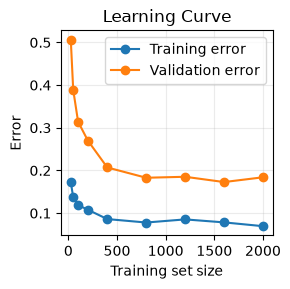

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

sample_sizes = np.array([25, 50, 100, 200, 400, 800, 1200, 1600, 2000])

train_error = (
    0.55 / np.sqrt(sample_sizes)
    + 0.06
    + np.random.normal(0, 0.006, len(sample_sizes))
)

val_error = (
    1.8 / np.sqrt(sample_sizes)
    + 0.14
    + np.random.normal(0, 0.012, len(sample_sizes))
)

plt.figure(figsize=(3, 3))

plt.plot(sample_sizes, train_error, "o-", label="Training error")
plt.plot(sample_sizes, val_error, "o-", label="Validation error")

plt.xlabel("Training set size")
plt.ylabel("Error")
plt.title("Learning Curve")
plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

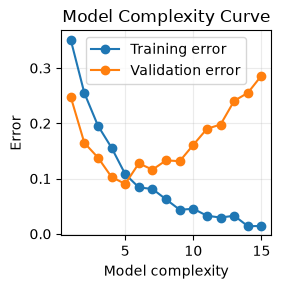

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Increasing model complexity
complexity = np.arange(1, 16)  # e.g. polynomial degree

# Training error decreases as the model becomes more flexible
train_error = (
    0.45 * np.exp(-complexity / 3)
    + 0.025
    + np.random.normal(0, 0.008, len(complexity))
)

# Validation error typically has a U-shape:
# high when the model is too simple,
# lowest at intermediate complexity,
# then increases due to overfitting
val_error = (
    0.35 * np.exp(-complexity / 2)
    + 0.04
    + 0.0025 * complexity**1.7
    + np.random.normal(0, 0.012, len(complexity))
)

# Prevent negative errors
train_error = np.clip(train_error, 0, None)
val_error = np.clip(val_error, 0, None)

# Plot
plt.figure(figsize=(3, 3))

plt.plot(
    complexity,
    train_error,
    "o-",
    label="Training error"
)

plt.plot(
    complexity,
    val_error,
    "o-",
    label="Validation error"
)

plt.xlabel("Model complexity")
plt.ylabel("Error")
plt.title("Model Complexity Curve")

plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

plt.show()

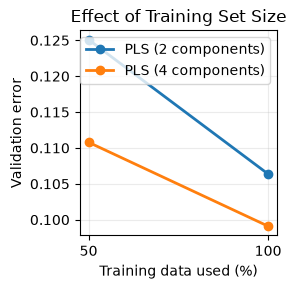

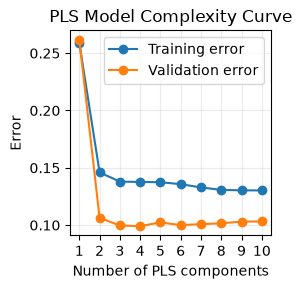

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


# ============================================================
# 1. Generate synthetic data
# ============================================================

np.random.seed(42)

n_samples = 400
n_features = 30

# Latent variables
Z = np.random.normal(size=(n_samples, 6))

# X is generated from latent variables
W = np.random.normal(size=(6, n_features))
X = Z @ W + 0.3 * np.random.normal(size=(n_samples, n_features))

# True response depends mainly on 4 latent components
true_coefs = np.array([2.0, 1.5, 1.0, 0.8, 0.0, 0.0])

y = Z @ true_coefs + 1.0 * np.random.normal(size=n_samples)

# Standardize X and y
X = (X - X.mean(axis=0)) / X.std(axis=0)
y = (y - y.mean()) / y.std()


# ============================================================
# 2. Train/test split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# ============================================================
# 3. Error as a function of training-set size
# ============================================================

fractions = np.array([0.5, 1.0])

components_to_compare = [2, 4]

results = {}

for n_components in components_to_compare:

    train_errors = []
    test_errors = []

    for fraction in fractions:

        n = int(len(X_train) * fraction)

        X_sub = X_train[:n]
        y_sub = y_train[:n]

        pls = PLSRegression(n_components=n_components)
        pls.fit(X_sub, y_sub)

        train_pred = pls.predict(X_sub).ravel()
        test_pred = pls.predict(X_test).ravel()

        train_errors.append(
            mean_squared_error(y_sub, train_pred)
        )

        test_errors.append(
            mean_squared_error(y_test, test_pred)
        )

    results[n_components] = {
        "train": train_errors,
        "test": test_errors
    }


# ============================================================
# 4. Plot: 50% vs 100% of training data
# ============================================================

x = np.array([50, 100])

plt.figure(figsize=(3, 3))

for n_components in components_to_compare:

    plt.plot(
        x,
        results[n_components]["test"],
        marker="o",
        linewidth=2,
        label=f"PLS ({n_components} components)"
    )

plt.xlabel("Training data used (%)")
plt.ylabel("Validation error")
plt.title("Effect of Training Set Size")
plt.xticks([50, 100])
plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()


# ============================================================
# 5. Complexity curve: 1–10 PLS components
# ============================================================

components = np.arange(1, 11)

train_errors = []
test_errors = []

for n_components in components:

    pls = PLSRegression(n_components=n_components)
    pls.fit(X_train, y_train)

    train_pred = pls.predict(X_train).ravel()
    test_pred = pls.predict(X_test).ravel()

    train_errors.append(
        mean_squared_error(y_train, train_pred)
    )

    test_errors.append(
        mean_squared_error(y_test, test_pred)
    )


# ============================================================
# 6. Plot complexity curve
# ============================================================

plt.figure(figsize=(3, 3))

plt.plot(
    components,
    train_errors,
    "o-",
    label="Training error"
)

plt.plot(
    components,
    test_errors,
    "o-",
    label="Validation error"
)

plt.xlabel("Number of PLS components")
plt.ylabel("Error")
plt.title("PLS Model Complexity Curve")
plt.xticks(components)
plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

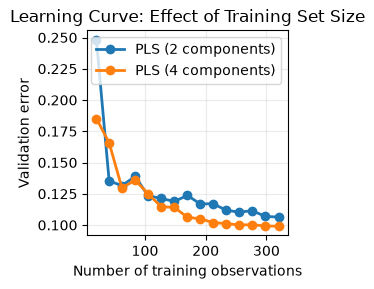

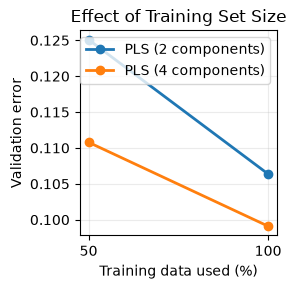

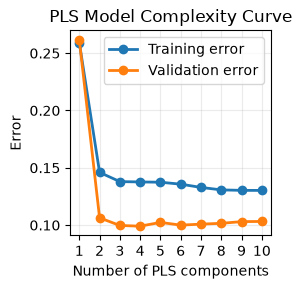

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


# ============================================================
# SETTINGS — EDIT THESE
# ============================================================

RANDOM_STATE = 42

N_SAMPLES = 400
N_FEATURES = 30
N_LATENT = 6

# Components used for the learning-curve comparison
LEARNING_CURVE_COMPONENTS = [2, 4]

# Components used for the 50% vs 100% comparison
DATA_SIZE_COMPONENTS = [2, 4]

# Components used for the complexity curve
COMPLEXITY_RANGE = range(1, 11)


# ============================================================
# 1. GENERATE SYNTHETIC DATA
# ============================================================

np.random.seed(RANDOM_STATE)

# Latent variables
Z = np.random.normal(
    size=(N_SAMPLES, N_LATENT)
)

# Generate observed X variables from latent variables
W = np.random.normal(
    size=(N_LATENT, N_FEATURES)
)

X = (
    Z @ W
    + 0.3 * np.random.normal(
        size=(N_SAMPLES, N_FEATURES)
    )
)

# ------------------------------------------------------------
# True relationship
#
# The response depends on the first 4 latent dimensions.
# Components 5 and 6 do not contain useful signal.
# ------------------------------------------------------------

true_coefs = np.array([
    2.0,
    1.5,
    1.0,
    0.8,
    0.0,
    0.0
])

y = (
    Z @ true_coefs
    + 1.0 * np.random.normal(size=N_SAMPLES)
)


# ============================================================
# 2. STANDARDIZE DATA
# ============================================================

X = (
    X - X.mean(axis=0)
) / X.std(axis=0)

y = (
    y - y.mean()
) / y.std()


# ============================================================
# 3. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)


# ============================================================
# 4. LEARNING CURVE
#
# Error as a function of number of observations.
#
# Compare 2-component and 4-component PLS.
# ============================================================

sample_sizes = np.linspace(
    20,
    len(X_train),
    15,
    dtype=int
)

plt.figure(figsize=(3, 3))

for n_components in LEARNING_CURVE_COMPONENTS:

    train_errors = []
    validation_errors = []

    for n in sample_sizes:

        # Use only n observations
        X_sub = X_train[:n]
        y_sub = y_train[:n]

        pls = PLSRegression(
            n_components=n_components
        )

        pls.fit(
            X_sub,
            y_sub
        )

        # Training error
        train_pred = (
            pls.predict(X_sub)
            .ravel()
        )

        # Validation error
        val_pred = (
            pls.predict(X_test)
            .ravel()
        )

        train_errors.append(
            mean_squared_error(
                y_sub,
                train_pred
            )
        )

        validation_errors.append(
            mean_squared_error(
                y_test,
                val_pred
            )
        )

    # Plot validation error
    plt.plot(
        sample_sizes,
        validation_errors,
        "o-",
        linewidth=2,
        label=f"PLS ({n_components} components)"
    )


plt.xlabel("Number of training observations")
plt.ylabel("Validation error")

plt.title(
    "Learning Curve: Effect of Training Set Size"
)

plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()


# ============================================================
# 5. 50% VS 100% OF THE DATA
#
# Compare the validation error of 2 vs 4 components
# when using 50% and 100% of the available training data.
# ============================================================

fractions = np.array([
    0.50,
    1.00
])

plt.figure(figsize=(3, 3))

for n_components in DATA_SIZE_COMPONENTS:

    validation_errors = []

    for fraction in fractions:

        n = int(
            len(X_train) * fraction
        )

        X_sub = X_train[:n]
        y_sub = y_train[:n]

        pls = PLSRegression(
            n_components=n_components
        )

        pls.fit(
            X_sub,
            y_sub
        )

        val_pred = (
            pls.predict(X_test)
            .ravel()
        )

        validation_errors.append(
            mean_squared_error(
                y_test,
                val_pred
            )
        )

    plt.plot(
        fractions * 100,
        validation_errors,
        "o-",
        linewidth=2,
        label=f"PLS ({n_components} components)"
    )


plt.xlabel("Training data used (%)")
plt.ylabel("Validation error")

plt.title(
    "Effect of Training Set Size"
)

plt.xticks(
    [50, 100]
)

plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()


# ============================================================
# 6. MODEL COMPLEXITY CURVE
#
# Increase PLS components from 1 to 10.
# ============================================================

components = np.array(
    list(COMPLEXITY_RANGE)
)

train_errors = []
validation_errors = []

for n_components in components:

    pls = PLSRegression(
        n_components=n_components
    )

    pls.fit(
        X_train,
        y_train
    )

    # Training predictions
    train_pred = (
        pls.predict(X_train)
        .ravel()
    )

    # Validation predictions
    val_pred = (
        pls.predict(X_test)
        .ravel()
    )

    train_errors.append(
        mean_squared_error(
            y_train,
            train_pred
        )
    )

    validation_errors.append(
        mean_squared_error(
            y_test,
            val_pred
        )
    )


# ============================================================
# 7. PLOT COMPLEXITY CURVE
# ============================================================

plt.figure(figsize=(3, 3))

plt.plot(
    components,
    train_errors,
    "o-",
    linewidth=2,
    label="Training error"
)

plt.plot(
    components,
    validation_errors,
    "o-",
    linewidth=2,
    label="Validation error"
)

plt.xlabel(
    "Number of PLS components"
)

plt.ylabel("Error")

plt.title(
    "PLS Model Complexity Curve"
)

plt.xticks(components)

plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

X shape: (120, 12)
Y shape: (120, 1)

Første 5 observasjoner:
[[-1.86173046 -0.03123422 -0.83644874 -1.17981318  1.44921302  0.33836905
   1.71534458 -1.90644956  0.76874775 -2.55339912  0.15333311 -1.41269426]
 [-0.37966946 -0.88869209  0.5010846  -1.283989   -0.98882051  0.2189534
  -0.51492964 -0.8783919  -0.7877977  -0.866967    1.85120995  1.79688486]
 [ 0.20496272  0.91354787  0.624665   -0.38601036 -1.00216085 -0.34869564
  -1.53266675  0.43766642 -0.58444804 -0.80073372 -0.06352202 -0.78113825]
 [ 1.38045621  3.51484477  1.13693471 -0.17306723  0.5939179  -0.23418688
  -0.27266691 -1.33172726 -0.52731448  0.6926121   0.18251335 -0.19680737]
 [-0.44235632  0.12344843  0.15041396 -0.50309688  0.13014251 -1.44275562
   1.33611015 -0.50344429  0.34092022 -0.50623985  0.75474766 -0.48009823]]

Første 5 Y:
[[-6.52432967]
 [ 2.38269507]
 [ 0.60388175]
 [-1.39005808]
 [-2.16005   ]]


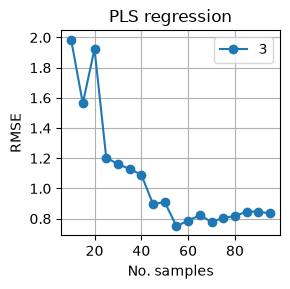

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline


# ============================================================
# 1. Lag dataset
# ============================================================

np.random.seed(50)

n_samples = 120
n_features = 12

# 5 latente variabler
latent = np.random.normal(size=(n_samples, 5))

# X har 12 dimensjoner.
# De første 5 har en tydelig struktur knyttet til de latente variablene.
X = np.zeros((n_samples, n_features))

# De 5 relevante dimensjonene
X[:, 0] = latent[:, 0] + 0.20 * np.random.normal(size=n_samples)
X[:, 1] = latent[:, 1] + 0.20 * np.random.normal(size=n_samples)
X[:, 2] = latent[:, 2] + 0.20 * np.random.normal(size=n_samples)
X[:, 3] = latent[:, 3] + 0.20 * np.random.normal(size=n_samples)
X[:, 4] = latent[:, 4] + 0.20 * np.random.normal(size=n_samples)

# De resterende dimensjonene
# lager vi som hovedsakelig støy
for j in range(5, 12):
    X[:, j] = np.random.normal(size=n_samples)


# ============================================================
# 2. Lag responsvariabel Y
# ============================================================

# Y avhenger av de 5 relevante dimensjonene
true_coefficients = np.array([
    2.0,
    -1.5,
    1.2,
    0.8,
    -1.0
])

Y = latent @ true_coefficients

# Litt måle-/observasjonsstøy
Y += 0.5 * np.random.normal(size=n_samples)

# Gjør Y til kolonnevektor
Y = Y.reshape(-1, 1)


# ============================================================
# 3. Se på datasettet
# ============================================================

print("X shape:", X.shape)
print("Y shape:", Y.shape)

print("\nFørste 5 observasjoner:")
print(X[:5])

print("\nFørste 5 Y:")
print(Y[:5])


# ============================================================
# 4. Learning curve for PLS
# ============================================================

# Vi bruker et fast testsett.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.20,
    random_state=42
)

# Antall observasjoner vi vil teste
training_sizes = np.arange(10, len(X_train) + 1, 5)

rmse_values = []

for n in training_sizes:

    # Bruk de første n observasjonene fra treningssettet
    X_train_subset = X_train[:n]
    y_train_subset = y_train[:n]

    # PLS-modell
    pls = make_pipeline(
        StandardScaler(),
        PLSRegression(n_components=3)
    )

    # Tren modellen
    pls.fit(X_train_subset, y_train_subset)

    # Prediker på TEST-settet
    y_pred = pls.predict(X_test)

    # RMSE
    rmse = np.sqrt(
        mean_squared_error(y_test, y_pred)
    )

    rmse_values.append(rmse)


# ============================================================
# 5. Plot learning curve
# ============================================================

plt.figure(figsize=(3, 3))

plt.plot(
    training_sizes,
    rmse_values,
    marker="o"
)

plt.xlabel("No. samples")
plt.ylabel("RMSE")
plt.title("PLS regression")
# plt.legend("3 components")

plt.grid(True)
plt.tight_layout()
plt.show()

c:\Users\jakobm\AppData\Local\anaconda3\envs\TK8117\Lib\site-packages\sklearn\cross_decomposition\_pls.py:308: UserWarning: y residual is constant at iteration 9
  warnings.warn(f"y residual is constant at iteration {k}")


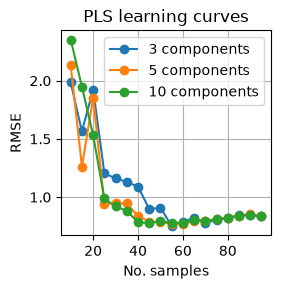

In [ ]:
# Learning curves for different numbers of PLS components

components_list = [3, 5, 10]

plt.figure(figsize=(3, 3))

for n_components in components_list:

    rmse_values = []

    for n in training_sizes:

        X_train_subset = X_train[:n]
        y_train_subset = y_train[:n]

        pls = make_pipeline(
            StandardScaler(),
            PLSRegression(n_components=n_components)
        )

        pls.fit(X_train_subset, y_train_subset)

        y_pred = pls.predict(X_test)

        rmse = np.sqrt(
            mean_squared_error(y_test, y_pred)
        )

        rmse_values.append(rmse)

    plt.plot(
        training_sizes,
        rmse_values,
        marker="o",
        label=f"{n_components} components"
    )

plt.xlabel("No. samples")
plt.ylabel("RMSE")
plt.title("PLS learning curves")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

c:\Users\jakobm\AppData\Local\anaconda3\envs\TK8117\Lib\site-packages\sklearn\cross_decomposition\_pls.py:308: UserWarning: y residual is constant at iteration 9
  warnings.warn(f"y residual is constant at iteration {k}")
c:\Users\jakobm\AppData\Local\anaconda3\envs\TK8117\Lib\site-packages\sklearn\cross_decomposition\_pls.py:308: UserWarning: y residual is constant at iteration 9
  warnings.warn(f"y residual is constant at iteration {k}")
c:\Users\jakobm\AppData\Local\anaconda3\envs\TK8117\Lib\site-packages\sklearn\cross_decomposition\_pls.py:308: UserWarning: y residual is constant at iteration 9
  warnings.warn(f"y residual is constant at iteration {k}")
c:\Users\jakobm\AppData\Local\anaconda3\envs\TK8117\Lib\site-packages\sklearn\cross_decomposition\_pls.py:308: UserWarning: y residual is constant at iteration 9
  warnings.warn(f"y residual is constant at iteration {k}")
c:\Users\jakobm\AppData\Local\anaconda3\envs\TK8117\Lib\site-packages\sklearn\cross_decomposition\_pls.py:308: U

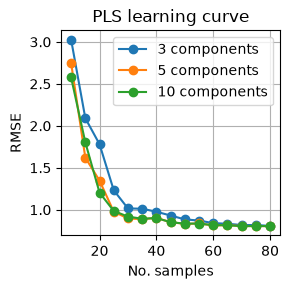

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error


# ============================================================
# 1. Create dataset
# ============================================================

np.random.seed(42)

n_samples = 100
n_features = 12


# ------------------------------------------------------------
# Latent structure
# ------------------------------------------------------------
# 10 underlying latent factors
latent = np.random.normal(
    0,
    1,
    size=(n_samples, 10)
)


# ------------------------------------------------------------
# Create X
# ------------------------------------------------------------

X = np.zeros((n_samples, n_features))


# 5 strong dimensions
for i in range(5):
    X[:, i] = (
        latent[:, i]
        + 0.15 * np.random.normal(size=n_samples)
    )


# 5 weaker dimensions
for i in range(5, 10):
    X[:, i] = (
        latent[:, i]
        + 0.30 * np.random.normal(size=n_samples)
    )


# 2 mostly noisy dimensions
X[:, 10] = np.random.normal(size=n_samples)
X[:, 11] = np.random.normal(size=n_samples)


# ------------------------------------------------------------
# Create Y
# ------------------------------------------------------------
# First 5 latent factors have strong influence.
# Next 5 have weaker influence.
#
# This creates a situation where increasing the number
# of PLS components can gradually capture more structure.

strong_effects = np.array([
    2.0,
    -1.8,
    1.6,
    -1.4,
    1.2
])

weak_effects = np.array([
    0.8,
    -0.7,
    0.6,
    -0.5,
    0.4
])


Y = (
    latent[:, :5] @ strong_effects
    + latent[:, 5:10] @ weak_effects
    + 0.25 * np.random.normal(size=n_samples)
)

Y = Y.reshape(-1, 1)


# ============================================================
# 2. Train / test split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.20,
    random_state=42
)


# ============================================================
# 3. Learning curve
# ============================================================

training_sizes = np.arange(10, 81, 5)

components_list = [3, 5, 10]

n_repeats = 30


results = {n: [] for n in components_list}


for n_components in components_list:

    for n in training_sizes:

        errors = []

        for repeat in range(n_repeats):

            # Randomly select n observations
            # from the training data
            rng = np.random.default_rng(
                1000 + repeat + n
            )

            indices = rng.choice(
                len(X_train),
                size=n,
                replace=False
            )

            X_subset = X_train[indices]
            y_subset = y_train[indices]


            # PLS model
            pls = make_pipeline(
                StandardScaler(),
                PLSRegression(
                    n_components=n_components
                )
            )


            # Fit
            pls.fit(
                X_subset,
                y_subset
            )


            # Predict test data
            y_pred = pls.predict(X_test)


            # RMSE
            rmse = np.sqrt(
                mean_squared_error(
                    y_test,
                    y_pred
                )
            )

            errors.append(rmse)


        # Average error over repetitions
        results[n_components].append(
            np.mean(errors)
        )


# ============================================================
# 4. Plot
# ============================================================

plt.figure(figsize=(3, 3))

for n_components in components_list:

    plt.plot(
        training_sizes,
        results[n_components],
        marker="o",
        label=f"{n_components} components"
    )


plt.xlabel("No. samples")
plt.ylabel("RMSE")

plt.title("PLS learning curve")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

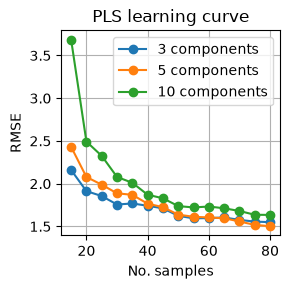

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error


# ============================================================
# 1. Create a more complex dataset
# ============================================================

np.random.seed(42)

n_samples = 100
n_features = 12


# ------------------------------------------------------------
# Latent variables
# ------------------------------------------------------------

n_latent = 8

latent = np.random.normal(
    0,
    1,
    size=(n_samples, n_latent)
)


# ------------------------------------------------------------
# Create correlated X variables
# ------------------------------------------------------------

X = np.zeros((n_samples, n_features))


# Each X variable is a mixture of several latent factors.
# This creates correlation and overlapping information.

loadings = np.array([
    [1.0,  0.2,  0.0,  0.0,  0.0,  0.0, 0.0, 0.0],
    [0.8,  0.5,  0.0,  0.0,  0.0,  0.0, 0.0, 0.0],
    [0.4,  0.9,  0.2,  0.0,  0.0,  0.0, 0.0, 0.0],

    [0.0,  0.7,  0.8,  0.0,  0.0,  0.0, 0.0, 0.0],
    [0.0,  0.3,  0.9,  0.4,  0.0,  0.0, 0.0, 0.0],

    [0.0,  0.0,  0.5,  0.9,  0.2,  0.0, 0.0, 0.0],
    [0.0,  0.0,  0.0,  0.8,  0.8,  0.0, 0.0, 0.0],

    [0.0,  0.0,  0.0,  0.2,  0.9,  0.5, 0.0, 0.0],
    [0.0,  0.0,  0.0,  0.0,  0.6,  0.9, 0.3, 0.0],

    [0.0,  0.0,  0.0,  0.0,  0.0,  0.7, 0.9, 0.3],
    [0.0,  0.0, 0.0,  0.0, 0.0, 0.0, 0.7, 0.9],
    [0.3,  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.8]
])


# Generate X
X = latent @ loadings.T


# Add measurement noise
X += 0.35 * np.random.normal(
    size=(n_samples, n_features)
)


# ============================================================
# 2. Create a complex response
# ============================================================

# Several latent factors contribute to Y,
# but with different strengths.

Y = (
    2.0 * latent[:, 0]
    + 1.6 * latent[:, 1]
    + 1.3 * latent[:, 2]
    + 1.0 * latent[:, 3]
    + 0.8 * latent[:, 4]
    + 0.6 * latent[:, 5]
    + 0.4 * latent[:, 6]
    + 0.3 * latent[:, 7]
)


# Add nonlinear structure that PLS cannot perfectly represent
Y += (
    0.7 * latent[:, 0]**2
    - 0.5 * latent[:, 2]**2
)


# Interaction between latent variables
Y += (
    0.6 * latent[:, 1] * latent[:, 3]
)


# Measurement noise in Y
Y += 1.0 * np.random.normal(
    size=n_samples
)


Y = Y.reshape(-1, 1)


# ============================================================
# 3. Train / test split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.20,
    random_state=42
)


# ============================================================
# 4. Learning curve
# ============================================================

training_sizes = np.arange(
    15,
    len(X_train) + 1,
    5
)

components_list = [3, 5, 10]

n_repeats = 50


results = {
    n: [] for n in components_list
}


for n_components in components_list:

    for n in training_sizes:

        errors = []

        for repeat in range(n_repeats):

            rng = np.random.default_rng(
                1000 + repeat
            )

            # Random subset of training observations
            indices = rng.choice(
                len(X_train),
                size=n,
                replace=False
            )

            X_subset = X_train[indices]
            y_subset = y_train[indices]


            # PLS model
            pls = make_pipeline(
                StandardScaler(),
                PLSRegression(
                    n_components=n_components
                )
            )


            pls.fit(
                X_subset,
                y_subset
            )


            # Predict test data
            y_pred = pls.predict(
                X_test
            )


            # RMSE
            rmse = np.sqrt(
                mean_squared_error(
                    y_test,
                    y_pred
                )
            )

            errors.append(rmse)


        results[n_components].append(
            np.mean(errors)
        )


# ============================================================
# 5. Plot learning curves
# ============================================================

plt.figure(figsize=(3, 3))

for n_components in components_list:

    plt.plot(
        training_sizes,
        results[n_components],
        marker="o",
        label=f"{n_components} components"
    )


plt.xlabel("No. samples")
plt.ylabel("RMSE")

plt.title("PLS learning curve")

plt.legend()

plt.grid(True)

plt.tight_layout()


plt.show()

c:\Users\jakobm\AppData\Local\anaconda3\envs\TK8117\Lib\site-packages\sklearn\cross_decomposition\_pls.py:308: UserWarning: y residual is constant at iteration 9
  warnings.warn(f"y residual is constant at iteration {k}")
c:\Users\jakobm\AppData\Local\anaconda3\envs\TK8117\Lib\site-packages\sklearn\cross_decomposition\_pls.py:308: UserWarning: y residual is constant at iteration 9
  warnings.warn(f"y residual is constant at iteration {k}")
c:\Users\jakobm\AppData\Local\anaconda3\envs\TK8117\Lib\site-packages\sklearn\cross_decomposition\_pls.py:308: UserWarning: y residual is constant at iteration 9
  warnings.warn(f"y residual is constant at iteration {k}")
c:\Users\jakobm\AppData\Local\anaconda3\envs\TK8117\Lib\site-packages\sklearn\cross_decomposition\_pls.py:308: UserWarning: y residual is constant at iteration 9
  warnings.warn(f"y residual is constant at iteration {k}")
c:\Users\jakobm\AppData\Local\anaconda3\envs\TK8117\Lib\site-packages\sklearn\cross_decomposition\_pls.py:308: U

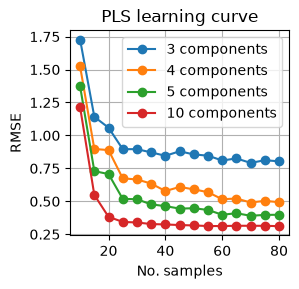

In [48]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error


# ============================================================
# 1. Create dataset
# ============================================================

np.random.seed(42)

n_samples = 100
n_features = 12


# ------------------------------------------------------------
# Latent structure
# ------------------------------------------------------------

n_latent = 10

latent = np.random.normal(
    0,
    1,
    size=(n_samples, n_latent)
)


# ------------------------------------------------------------
# X variables
# ------------------------------------------------------------

# Each pair of X variables describes one latent direction.
# This gives 10 meaningful latent directions in only
# 12 measured variables.

loadings = np.array([
    [1.00, 0.20, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00],
    [0.80, 0.60, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00],

    [0.00, 1.00, 0.20, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00],
    [0.00, 0.70, 0.80, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00],

    [0.00, 0.00, 1.00, 0.20, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00],
    [0.00, 0.00, 0.60, 0.90, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00],

    [0.00, 0.00, 0.00, 0.00, 1.00, 0.20, 0.00, 0.00, 0.00, 0.00],
    [0.00, 0.00, 0.00, 0.00, 0.60, 0.90, 0.00, 0.00, 0.00, 0.00],

    [0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 1.00, 0.20, 0.00, 0.00],
    [0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.60, 0.90, 0.00, 0.00],

    [0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 1.00, 0.40],
    [0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.50, 0.90],
])

X = latent @ loadings.T


# Very small measurement noise
X += 0.05 * np.random.normal(
    size=X.shape
)


# ============================================================
# 2. Create Y
# ============================================================

# All 10 latent dimensions contain useful information.
#
# This means PLS needs sufficient complexity to describe Y.
#
# However, the signal-to-noise ratio is high enough that
# relatively few observations are already sufficient.

effects = np.array([
    3.0,
    2.7,
    2.4,
    2.1,
    1.8,
    1.5,
    1.2,
    1.0,
    0.8,
    0.6
])

Y = latent @ effects


# Low irreducible noise
Y += 0.15 * np.random.normal(
    size=n_samples
)

Y = Y.reshape(-1, 1)


# ============================================================
# 3. Train / test split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.20,
    random_state=42
)


# ============================================================
# 4. Learning curves
# ============================================================

training_sizes = np.arange(
    10,
    81,
    5
)

components_list = [3, 4, 5, 10]

n_repeats = 50


results = {
    n: [] for n in components_list
}


for n_components in components_list:

    for n in training_sizes:

        errors = []

        for repeat in range(n_repeats):

            rng = np.random.default_rng(
                1000 + repeat
            )

            indices = rng.choice(
                len(X_train),
                size=n,
                replace=False
            )

            X_subset = X_train[indices]
            y_subset = y_train[indices]


            # PLS model
            pls = make_pipeline(
                StandardScaler(),
                PLSRegression(
                    n_components=n_components
                )
            )


            pls.fit(
                X_subset,
                y_subset
            )


            # Test prediction
            y_pred = pls.predict(
                X_test
            )


            # RMSE
            rmse = np.sqrt(
                mean_squared_error(
                    y_test,
                    y_pred
                )
            )

            errors.append(rmse)


        results[n_components].append(
            np.mean(errors)
        )


# ============================================================
# 5. Plot
# ============================================================

plt.figure(figsize=(3, 3))

for n_components in components_list:

    plt.plot(
        training_sizes,
        results[n_components],
        marker="o",
        label=f"{n_components} components"
    )


plt.xlabel("No. samples")
plt.ylabel("RMSE")

plt.title("PLS learning curve")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

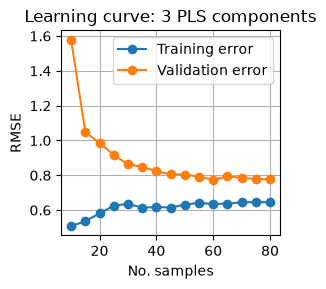

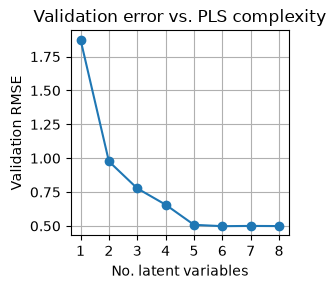

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error


# ============================================================
# 1. Create synthetic data
# ============================================================

np.random.seed(42)

n_samples = 100
n_features = 12
n_latent = 8

# 8 underlying latent factors
Z = np.random.normal(size=(n_samples, n_latent))

# Correlated measured X variables
loadings = np.array([
    [1.0, 0.3, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [0.8, 0.6, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],

    [0.0, 1.0, 0.3, 0.0, 0.0, 0.0, 0.0, 0.0],
    [0.0, 0.7, 0.8, 0.0, 0.0, 0.0, 0.0, 0.0],

    [0.0, 0.0, 1.0, 0.3, 0.0, 0.0, 0.0, 0.0],
    [0.0, 0.0, 0.6, 0.8, 0.0, 0.0, 0.0, 0.0],

    [0.0, 0.0, 0.0, 0.0, 1.0, 0.3, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 0.6, 0.8, 0.0, 0.0],

    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.3],
    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.6, 0.8],

    [0.5, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5, 0.0],
    [0.0, 0.4, 0.0, 0.0, 0.0, 0.0, 0.0, 0.7],
])

X = Z @ loadings.T

# Moderate measurement noise
X += 0.15 * np.random.normal(size=X.shape)


# ============================================================
# 2. Response depends on all 8 latent factors
# ============================================================

effects = np.array([
    3.0,
    2.6,
    2.2,
    1.8,
    1.4,
    1.1,
    0.8,
    0.6
])

Y = Z @ effects

# Small irreducible noise
Y += 0.25 * np.random.normal(size=n_samples)

Y = Y.reshape(-1, 1)


# ============================================================
# 3. Train / validation split
# ============================================================

X_train, X_val, y_train, y_val = train_test_split(
    X,
    Y,
    test_size=0.20,
    random_state=42
)


# ============================================================
# 4. Learning curve:
#    deliberately under-complex model = 3 PLS components
# ============================================================

training_sizes = np.arange(10, 81, 5)

n_repeats = 40

train_errors = []
val_errors = []

for n in training_sizes:

    train_rmse = []
    val_rmse = []

    for repeat in range(n_repeats):

        rng = np.random.default_rng(1000 + repeat)

        indices = rng.choice(
            len(X_train),
            size=n,
            replace=False
        )

        X_subset = X_train[indices]
        y_subset = y_train[indices]

        pls = make_pipeline(
            StandardScaler(),
            PLSRegression(n_components=3)
        )

        pls.fit(X_subset, y_subset)

        # Training error
        y_train_pred = pls.predict(X_subset)

        train_rmse.append(
            np.sqrt(
                mean_squared_error(
                    y_subset,
                    y_train_pred
                )
            )
        )

        # Validation error
        y_val_pred = pls.predict(X_val)

        val_rmse.append(
            np.sqrt(
                mean_squared_error(
                    y_val,
                    y_val_pred
                )
            )
        )

    train_errors.append(np.mean(train_rmse))
    val_errors.append(np.mean(val_rmse))


# ============================================================
# 5. Plot training and validation error
# ============================================================

plt.figure(figsize=(3, 3))

plt.plot(
    training_sizes,
    train_errors,
    marker="o",
    label="Training error"
)

plt.plot(
    training_sizes,
    val_errors,
    marker="o",
    label="Validation error"
)

plt.xlabel("No. samples")
plt.ylabel("RMSE")
plt.title("Learning curve: 3 PLS components")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# 6. Validation error vs. number of latent variables
# ============================================================

components = np.arange(1, 9)

component_errors = []

for n_components in components:

    errors = []

    for repeat in range(40):

        rng = np.random.default_rng(5000 + repeat)

        # Use the full training set, but bootstrap/subsample
        # slightly to make the result more stable
        indices = rng.choice(
            len(X_train),
            size=len(X_train),
            replace=False
        )

        X_subset = X_train[indices]
        y_subset = y_train[indices]

        pls = make_pipeline(
            StandardScaler(),
            PLSRegression(
                n_components=n_components
            )
        )

        pls.fit(X_subset, y_subset)

        y_pred = pls.predict(X_val)

        errors.append(
            np.sqrt(
                mean_squared_error(
                    y_val,
                    y_pred
                )
            )
        )

    component_errors.append(np.mean(errors))


# ============================================================
# 7. Plot validation error vs. latent variables
# ============================================================

plt.figure(figsize=(3, 3))

plt.plot(
    components,
    component_errors,
    marker="o"
)

plt.xlabel("No. latent variables")
plt.ylabel("Validation RMSE")
plt.title("Validation error vs. PLS complexity")
plt.xticks(components)
plt.grid(True)
plt.tight_layout()
plt.show()

c:\Users\jakobm\AppData\Local\anaconda3\envs\TK8117\Lib\site-packages\sklearn\cross_decomposition\_pls.py:308: UserWarning: y residual is constant at iteration 9
  warnings.warn(f"y residual is constant at iteration {k}")
c:\Users\jakobm\AppData\Local\anaconda3\envs\TK8117\Lib\site-packages\sklearn\cross_decomposition\_pls.py:308: UserWarning: y residual is constant at iteration 9
  warnings.warn(f"y residual is constant at iteration {k}")
c:\Users\jakobm\AppData\Local\anaconda3\envs\TK8117\Lib\site-packages\sklearn\cross_decomposition\_pls.py:308: UserWarning: y residual is constant at iteration 9
  warnings.warn(f"y residual is constant at iteration {k}")
c:\Users\jakobm\AppData\Local\anaconda3\envs\TK8117\Lib\site-packages\sklearn\cross_decomposition\_pls.py:308: UserWarning: y residual is constant at iteration 9
  warnings.warn(f"y residual is constant at iteration {k}")
c:\Users\jakobm\AppData\Local\anaconda3\envs\TK8117\Lib\site-packages\sklearn\cross_decomposition\_pls.py:308: U

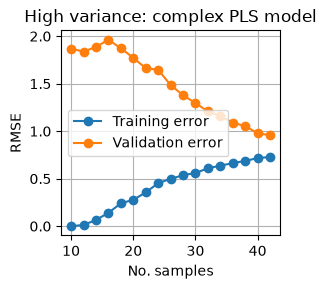

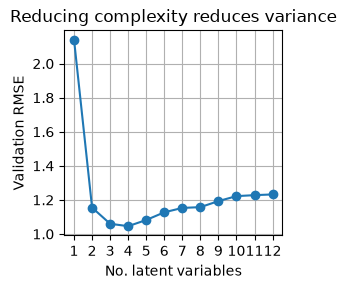

In [52]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error


# ============================================================
# 1. Create synthetic data
# ============================================================

np.random.seed(42)

n_samples = 60
n_features = 20
n_latent = 5

# Underlying latent variables
Z = np.random.normal(size=(n_samples, n_latent))

# Create correlated measured X variables
loadings = np.random.normal(
    0,
    1,
    size=(n_features, n_latent)
)

X = Z @ loadings.T

# Measurement noise
X += 0.4 * np.random.normal(
    size=X.shape
)

# Only a few latent variables truly determine Y
effects = np.array([
    3.0,
    2.0,
    1.2,
    0.0,
    0.0
])

Y = Z @ effects

# Response noise
Y += 0.8 * np.random.normal(
    size=n_samples
)

Y = Y.reshape(-1, 1)


# ============================================================
# 2. Train / validation split
# ============================================================

X_train, X_val, y_train, y_val = train_test_split(
    X,
    Y,
    test_size=0.30,
    random_state=42
)


# ============================================================
# 3. Learning curve using a deliberately complex model
# ============================================================

# 12 components is intentionally too complex
# for the amount of data available.

n_components = 10

training_sizes = np.arange(
    10,
    len(X_train) + 1,
    2
)

n_repeats = 50

train_errors = []
val_errors = []


for n in training_sizes:

    train_rmse = []
    val_rmse = []

    for repeat in range(n_repeats):

        rng = np.random.default_rng(
            1000 + repeat
        )

        indices = rng.choice(
            len(X_train),
            size=n,
            replace=False
        )

        X_subset = X_train[indices]
        y_subset = y_train[indices]

        pls = make_pipeline(
            StandardScaler(),
            PLSRegression(
                n_components=n_components
            )
        )

        pls.fit(
            X_subset,
            y_subset
        )

        # Training error
        y_train_pred = pls.predict(
            X_subset
        )

        train_rmse.append(
            np.sqrt(
                mean_squared_error(
                    y_subset,
                    y_train_pred
                )
            )
        )

        # Validation error
        y_val_pred = pls.predict(
            X_val
        )

        val_rmse.append(
            np.sqrt(
                mean_squared_error(
                    y_val,
                    y_val_pred
                )
            )
        )

    train_errors.append(
        np.mean(train_rmse)
    )

    val_errors.append(
        np.mean(val_rmse)
    )


# ============================================================
# 4. Plot learning curve
# ============================================================

plt.figure(figsize=(3, 3))

plt.plot(
    training_sizes,
    train_errors,
    marker="o",
    label="Training error"
)

plt.plot(
    training_sizes,
    val_errors,
    marker="o",
    label="Validation error"
)

plt.xlabel("No. samples")
plt.ylabel("RMSE")

plt.title(
    "High variance: complex PLS model"
)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# 5. Validation error vs. model complexity
# ============================================================

components = np.arange(
    1,
    13
)

component_errors = []

for n_components in components:

    errors = []

    for repeat in range(100):

        # Random train/validation split for each repeat
        rng = np.random.default_rng(
            5000 + repeat
        )

        indices = rng.permutation(
            len(X)
        )

        split = int(
            0.70 * len(X)
        )

        train_idx = indices[:split]
        val_idx = indices[split:]

        pls = make_pipeline(
            StandardScaler(),
            PLSRegression(
                n_components=n_components
            )
        )

        pls.fit(
            X[train_idx],
            Y[train_idx]
        )

        y_pred = pls.predict(
            X[val_idx]
        )

        errors.append(
            np.sqrt(
                mean_squared_error(
                    Y[val_idx],
                    y_pred
                )
            )
        )

    component_errors.append(
        np.mean(errors)
    )


# ============================================================
# 6. Plot validation error vs. complexity
# ============================================================

plt.figure(figsize=(3, 3))

plt.plot(
    components,
    component_errors,
    marker="o"
)

plt.xlabel("No. latent variables")
plt.ylabel("Validation RMSE")

plt.title(
    "Reducing complexity reduces variance"
)

plt.xticks(components)
plt.grid(True)
plt.tight_layout()
plt.show()

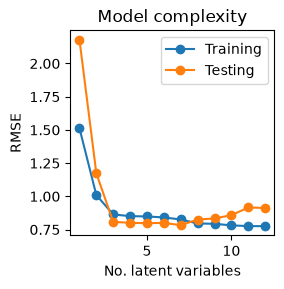

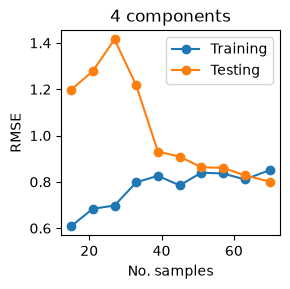

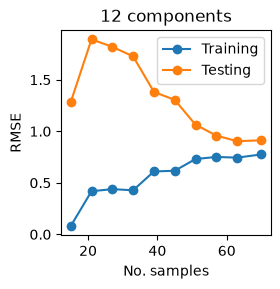

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# --------------------------------------------------
# 1. Generate synthetic data
# --------------------------------------------------

np.random.seed(42)

n_samples = 100
n_features = 20
n_latent = 8

Z = np.random.normal(size=(n_samples, n_latent))

loadings = np.random.normal(size=(n_latent, n_features))

X = Z @ loadings + 0.35 * np.random.normal(
    size=(n_samples, n_features)
)

# First 4 latent factors contain true signal
true_effects = np.array([3.0, 2.2, 1.5, 0.8, 0, 0, 0, 0])

Y = (
    Z @ true_effects
    + 0.8 * np.random.normal(size=n_samples)
)

X_train, X_test, y_train, y_test = train_test_split(
    X, Y,
    test_size=0.30,
    random_state=42
)

# --------------------------------------------------
# 2. Test error vs model complexity
# --------------------------------------------------

components = range(1, 13)

train_rmse = []
test_rmse = []

for n_comp in components:

    model = PLSRegression(n_components=n_comp)

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train).ravel()
    y_test_pred = model.predict(X_test).ravel()

    train_rmse.append(
        np.sqrt(mean_squared_error(y_train, y_train_pred))
    )

    test_rmse.append(
        np.sqrt(mean_squared_error(y_test, y_test_pred))
    )

# --------------------------------------------------
# 3. Plot 1: Model complexity
# --------------------------------------------------

plt.figure(figsize=(3, 3))

plt.plot(
    components,
    train_rmse,
    marker="o",
    label="Training"
)

plt.plot(
    components,
    test_rmse,
    marker="o",
    label="Testing"
)

plt.xlabel("No. latent variables")
plt.ylabel("RMSE")
plt.title("Model complexity")
plt.legend()

plt.tight_layout()
plt.show()


# --------------------------------------------------
# 4. Learning curves for 4 and 12 components
# --------------------------------------------------

sample_sizes = np.linspace(
    15,
    len(X_train),
    10,
    dtype=int
)

learning_curves = {}

for n_comp in [4, 12]:

    train_errors = []
    test_errors = []

    for n in sample_sizes:

        X_sub = X_train[:n]
        y_sub = y_train[:n]

        model = PLSRegression(
            n_components=n_comp
        )

        model.fit(X_sub, y_sub)

        y_train_pred = model.predict(X_sub).ravel()
        y_test_pred = model.predict(X_test).ravel()

        train_errors.append(
            np.sqrt(
                mean_squared_error(
                    y_sub,
                    y_train_pred
                )
            )
        )

        test_errors.append(
            np.sqrt(
                mean_squared_error(
                    y_test,
                    y_test_pred
                )
            )
        )

    learning_curves[n_comp] = (
        train_errors,
        test_errors
    )


# --------------------------------------------------
# 5. Plot 2: Learning curve - 4 components
# --------------------------------------------------

train_4, test_4 = learning_curves[4]

plt.figure(figsize=(3, 3))

plt.plot(
    sample_sizes,
    train_4,
    marker="o",
    label="Training"
)

plt.plot(
    sample_sizes,
    test_4,
    marker="o",
    label="Testing"
)

plt.xlabel("No. samples")
plt.ylabel("RMSE")
plt.title("4 components")
plt.legend()

plt.tight_layout()
plt.show()


# --------------------------------------------------
# 6. Plot 3: Learning curve - 12 components
# --------------------------------------------------

train_12, test_12 = learning_curves[12]

plt.figure(figsize=(3, 3))

plt.plot(
    sample_sizes,
    train_12,
    marker="o",
    label="Training"
)

plt.plot(
    sample_sizes,
    test_12,
    marker="o",
    label="Testing"
)

plt.xlabel("No. samples")
plt.ylabel("RMSE")
plt.title("12 components")
plt.legend()

plt.tight_layout()
plt.show()

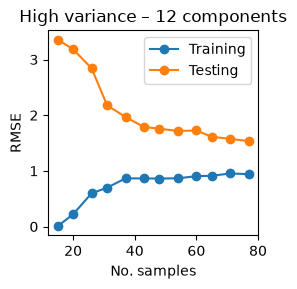

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# --------------------------------------------------
# 1. Generate synthetic data
# --------------------------------------------------

np.random.seed(42)

n_samples = 110       # 50 more samples
n_features = 20
n_latent = 5

# Latent variables
Z = np.random.normal(size=(n_samples, n_latent))

# Correlated X variables
loadings = np.random.normal(
    size=(n_latent, n_features)
)

X = Z @ loadings + 0.5 * np.random.normal(
    size=(n_samples, n_features)
)

# Only first 3 latent variables contain true signal
true_effects = np.array([
    3.0,
    2.0,
    1.0,
    0.0,
    0.0
])

Y = (
    Z @ true_effects
    + 1.0 * np.random.normal(size=n_samples)
)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.30,
    random_state=42
)

# --------------------------------------------------
# 2. Learning curve for an overly complex model
# --------------------------------------------------

n_components = 12

sample_sizes = np.linspace(
    15,
    len(X_train),
    12,
    dtype=int
)

train_rmse = []
test_rmse = []

for n in sample_sizes:

    X_sub = X_train[:n]
    y_sub = y_train[:n]

    model = PLSRegression(
        n_components=n_components
    )

    model.fit(X_sub, y_sub)

    y_train_pred = model.predict(
        X_sub
    ).ravel()

    y_test_pred = model.predict(
        X_test
    ).ravel()

    train_rmse.append(
        np.sqrt(
            mean_squared_error(
                y_sub,
                y_train_pred
            )
        )
    )

    test_rmse.append(
        np.sqrt(
            mean_squared_error(
                y_test,
                y_test_pred
            )
        )
    )

# --------------------------------------------------
# 3. Plot learning curve
# --------------------------------------------------

plt.figure(figsize=(3, 3))

plt.plot(
    sample_sizes,
    train_rmse,
    marker="o",
    label="Training"
)

plt.plot(
    sample_sizes,
    test_rmse,
    marker="o",
    label="Testing"
)

plt.xlabel("No. samples")
plt.ylabel("RMSE")
plt.title("High variance – 12 components")

plt.legend()

plt.tight_layout()
plt.show()

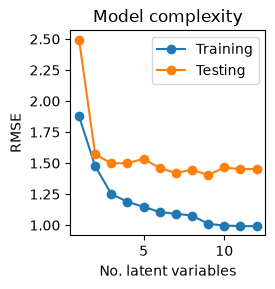

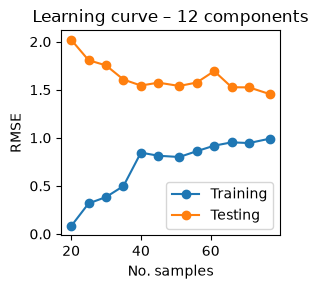

In [57]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


# ==================================================
# 1. Generate data
# ==================================================

np.random.seed(42)

n_samples = 110
n_features = 20
n_latent = 8

# Latent variables
Z = np.random.normal(
    0, 1,
    size=(n_samples, n_latent)
)

# Correlated X variables
loadings = np.random.normal(
    0, 1,
    size=(n_latent, n_features)
)

X = (
    Z @ loadings
    + 0.50 * np.random.normal(
        size=(n_samples, n_features)
    )
)

# Only first 3 latent variables contain
# meaningful information about Y
true_effects = np.array([
    3.0,
    2.0,
    1.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0
])

Y = (
    Z @ true_effects
    + 1.0 * np.random.normal(size=n_samples)
)


# ==================================================
# 2. Train/test split
# ==================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.30,
    random_state=42
)


# ==================================================
# 3. Complexity curve
# ==================================================

components = range(1, 13)

train_rmse = []
test_rmse = []

for n_comp in components:

    model = PLSRegression(
        n_components=n_comp
    )

    model.fit(
        X_train,
        y_train
    )

    y_train_pred = model.predict(
        X_train
    ).ravel()

    y_test_pred = model.predict(
        X_test
    ).ravel()

    train_rmse.append(
        np.sqrt(
            mean_squared_error(
                y_train,
                y_train_pred
            )
        )
    )

    test_rmse.append(
        np.sqrt(
            mean_squared_error(
                y_test,
                y_test_pred
            )
        )
    )


# ==================================================
# 4. Plot complexity curve
# ==================================================

plt.figure(figsize=(3, 3))

plt.plot(
    components,
    train_rmse,
    marker="o",
    label="Training"
)

plt.plot(
    components,
    test_rmse,
    marker="o",
    label="Testing"
)

plt.xlabel("No. latent variables")
plt.ylabel("RMSE")
plt.title("Model complexity")

plt.legend()

plt.tight_layout()
plt.show()


# ==================================================
# 5. Learning curve for 12 components
# ==================================================

n_comp = 12

sample_sizes = np.linspace(
    20,
    len(X_train),
    12,
    dtype=int
)

learning_train = []
learning_test = []

for n in sample_sizes:

    X_sub = X_train[:n]
    y_sub = y_train[:n]

    model = PLSRegression(
        n_components=n_comp
    )

    model.fit(
        X_sub,
        y_sub
    )

    y_train_pred = model.predict(
        X_sub
    ).ravel()

    y_test_pred = model.predict(
        X_test
    ).ravel()

    learning_train.append(
        np.sqrt(
            mean_squared_error(
                y_sub,
                y_train_pred
            )
        )
    )

    learning_test.append(
        np.sqrt(
            mean_squared_error(
                y_test,
                y_test_pred
            )
        )
    )


# ==================================================
# 6. Plot learning curve
# ==================================================

plt.figure(figsize=(3, 3))

plt.plot(
    sample_sizes,
    learning_train,
    marker="o",
    label="Training"
)

plt.plot(
    sample_sizes,
    learning_test,
    marker="o",
    label="Testing"
)

plt.xlabel("No. samples")
plt.ylabel("RMSE")
plt.title("Learning curve – 12 components")

plt.legend()

plt.tight_layout()
plt.show()

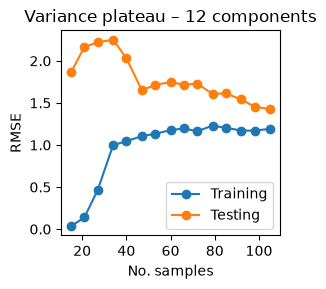

In [58]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


# ==================================================
# 1. Generate synthetic data
# ==================================================

np.random.seed(42)

n_samples = 150
n_features = 20
n_latent = 8

# Latent structure
Z = np.random.normal(
    size=(n_samples, n_latent)
)

# Correlated X variables
loadings = np.random.normal(
    size=(n_latent, n_features)
)

X = (
    Z @ loadings
    + 0.45 * np.random.normal(
        size=(n_samples, n_features)
    )
)

# Only first 3 latent variables contain signal
true_effects = np.array([
    3.0,
    2.0,
    1.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0
])

Y = (
    Z @ true_effects
    + 1.2 * np.random.normal(
        size=n_samples
    )
)


# ==================================================
# 2. Train/test split
# ==================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.30,
    random_state=42
)


# ==================================================
# 3. Learning curve
# ==================================================

n_components = 12

sample_sizes = np.linspace(
    15,
    len(X_train),
    15,
    dtype=int
)

train_rmse = []
test_rmse = []

for n in sample_sizes:

    model = PLSRegression(
        n_components=n_components
    )

    model.fit(
        X_train[:n],
        y_train[:n]
    )

    y_train_pred = model.predict(
        X_train[:n]
    ).ravel()

    y_test_pred = model.predict(
        X_test
    ).ravel()

    train_rmse.append(
        np.sqrt(
            mean_squared_error(
                y_train[:n],
                y_train_pred
            )
        )
    )

    test_rmse.append(
        np.sqrt(
            mean_squared_error(
                y_test,
                y_test_pred
            )
        )
    )


# ==================================================
# 4. Plot
# ==================================================

plt.figure(figsize=(3, 3))

plt.plot(
    sample_sizes,
    train_rmse,
    marker="o",
    label="Training"
)

plt.plot(
    sample_sizes,
    test_rmse,
    marker="o",
    label="Testing"
)

plt.xlabel("No. samples")
plt.ylabel("RMSE")
plt.title("Variance plateau – 12 components")

plt.legend()

plt.tight_layout()
plt.show()

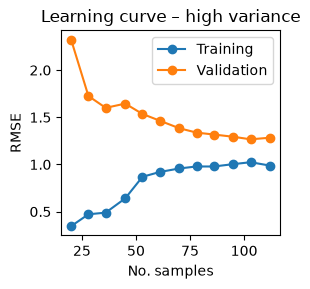

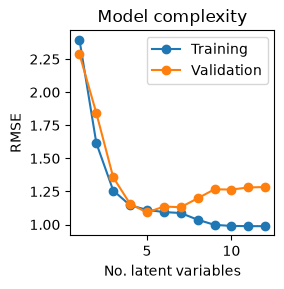

In [59]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


# ============================================================
# 1. GENERATE SYNTHETIC DATA
# ============================================================

np.random.seed(42)

n_samples = 160
n_features = 20
n_latent = 8

# Latent variables
Z = np.random.normal(
    size=(n_samples, n_latent)
)

# Correlated measured variables
loadings = np.random.normal(
    size=(n_latent, n_features)
)

X = (
    Z @ loadings
    + 0.45 * np.random.normal(
        size=(n_samples, n_features)
    )
)

# Only first 4 latent variables contain real signal
true_effects = np.array([
    3.0,
    2.2,
    1.4,
    0.8,
    0.0,
    0.0,
    0.0,
    0.0
])

# Response with moderate noise
Y = (
    Z @ true_effects
    + 1.0 * np.random.normal(
        size=n_samples
    )
)


# ============================================================
# 2. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.30,
    random_state=42
)


# ============================================================
# 3. LEARNING CURVE
#    High variance model = 12 components
# ============================================================

n_components = 12

sample_sizes = np.linspace(
    20,
    len(X_train),
    12,
    dtype=int
)

train_rmse = []
test_rmse = []

for n in sample_sizes:

    model = PLSRegression(
        n_components=n_components
    )

    model.fit(
        X_train[:n],
        y_train[:n]
    )

    y_train_pred = model.predict(
        X_train[:n]
    ).ravel()

    y_test_pred = model.predict(
        X_test
    ).ravel()

    train_rmse.append(
        np.sqrt(
            mean_squared_error(
                y_train[:n],
                y_train_pred
            )
        )
    )

    test_rmse.append(
        np.sqrt(
            mean_squared_error(
                y_test,
                y_test_pred
            )
        )
    )


# ============================================================
# 4. PLOT LEARNING CURVE
# ============================================================

plt.figure(figsize=(3, 3))

plt.plot(
    sample_sizes,
    train_rmse,
    marker="o",
    label="Training"
)

plt.plot(
    sample_sizes,
    test_rmse,
    marker="o",
    label="Validation"
)

plt.xlabel("No. samples")
plt.ylabel("RMSE")
plt.title("Learning curve – high variance")

plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 5. COMPLEXITY CURVE
# ============================================================

components = range(1, 13)

complexity_train = []
complexity_test = []

for n_comp in components:

    model = PLSRegression(
        n_components=n_comp
    )

    model.fit(
        X_train,
        y_train
    )

    y_train_pred = model.predict(
        X_train
    ).ravel()

    y_test_pred = model.predict(
        X_test
    ).ravel()

    complexity_train.append(
        np.sqrt(
            mean_squared_error(
                y_train,
                y_train_pred
            )
        )
    )

    complexity_test.append(
        np.sqrt(
            mean_squared_error(
                y_test,
                y_test_pred
            )
        )
    )


# ============================================================
# 6. PLOT COMPLEXITY CURVE
# ============================================================

plt.figure(figsize=(3, 3))

plt.plot(
    components,
    complexity_train,
    marker="o",
    label="Training"
)

plt.plot(
    components,
    complexity_test,
    marker="o",
    label="Validation"
)

plt.xlabel("No. latent variables")
plt.ylabel("RMSE")
plt.title("Model complexity")

plt.legend()

plt.tight_layout()
plt.show()

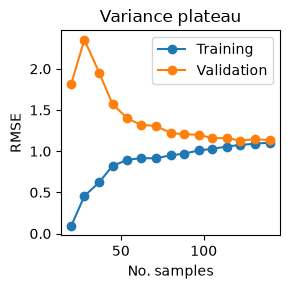

In [60]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

np.random.seed(42)

# -------------------------
# Synthetic dataset
# -------------------------
n_samples = 200
n_features = 25
n_latent = 8

# Latent structure
Z = np.random.normal(size=(n_samples, n_latent))

# Correlated measured X variables
loadings = np.random.normal(size=(n_latent, n_features))
X = Z @ loadings + 0.50 * np.random.normal(
    size=(n_samples, n_features)
)

# Only first 4 latent factors contain true signal
true_effects = np.array([
    3.0, 2.2, 1.5, 0.8,
    0.0, 0.0, 0.0, 0.0
])

# Response
Y = (
    Z @ true_effects
    + 1.0 * np.random.normal(size=n_samples)
)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, Y,
    test_size=0.30,
    random_state=42
)

# -------------------------
# Learning curve
# -------------------------
n_components = 12

sample_sizes = np.linspace(
    20,
    len(X_train),
    15,
    dtype=int
)

train_rmse = []
test_rmse = []

for n in sample_sizes:

    model = PLSRegression(
        n_components=n_components
    )

    model.fit(
        X_train[:n],
        y_train[:n]
    )

    # Training error
    y_train_pred = model.predict(
        X_train[:n]
    ).ravel()

    # Validation/test error
    y_test_pred = model.predict(
        X_test
    ).ravel()

    train_rmse.append(
        np.sqrt(
            mean_squared_error(
                y_train[:n],
                y_train_pred
            )
        )
    )

    test_rmse.append(
        np.sqrt(
            mean_squared_error(
                y_test,
                y_test_pred
            )
        )
    )

# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(3, 3))

plt.plot(
    sample_sizes,
    train_rmse,
    marker="o",
    label="Training"
)

plt.plot(
    sample_sizes,
    test_rmse,
    marker="o",
    label="Validation"
)

plt.xlabel("No. samples")
plt.ylabel("RMSE")
plt.title("Variance plateau")

plt.legend()
plt.tight_layout()
plt.show()

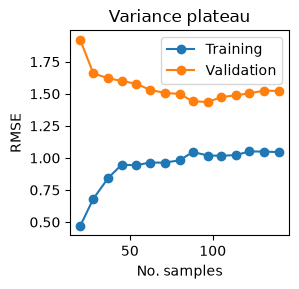

In [63]:
# Dataset
n_samples = 200
n_features = 25
n_latent = 8

Z = np.random.normal(size=(n_samples, n_latent))

loadings = np.random.normal(
    size=(n_latent, n_features)
)

X = (
    Z @ loadings
    + 0.50 * np.random.normal(
        size=(n_samples, n_features)
    )
)

true_effects = np.array([
    3.0, 2.2, 1.5, 0.8,
    0.0, 0.0, 0.0, 0.0
])

Y = (
    Z @ true_effects
    + 1.0 * np.random.normal(size=n_samples)
)

# Moderately complex model
n_components = 8

Z = np.random.normal(size=(n_samples, n_latent))

loadings = np.random.normal(
    size=(n_latent, n_features)
)

X = (
    Z @ loadings
    + 0.60 * np.random.normal(
        size=(n_samples, n_features)
    )
)

# Four latent factors contain signal
true_effects = np.array([
    3.0, 2.2, 1.5, 0.8,
    0.0, 0.0, 0.0, 0.0
])

Y = (
    Z @ true_effects
    + 1.2 * np.random.normal(size=n_samples)
)

X_train, X_test, y_train, y_test = train_test_split(
    X, Y,
    test_size=0.30,
    random_state=42
)

# -------------------------
# Learning curve
# -------------------------
n_components = 8

sample_sizes = np.linspace(
    20,
    len(X_train),
    15,
    dtype=int
)

train_rmse = []
test_rmse = []

for n in sample_sizes:

    model = PLSRegression(
        n_components=n_components
    )

    model.fit(
        X_train[:n],
        y_train[:n]
    )

    y_train_pred = model.predict(
        X_train[:n]
    ).ravel()

    y_test_pred = model.predict(
        X_test
    ).ravel()

    train_rmse.append(
        np.sqrt(
            mean_squared_error(
                y_train[:n],
                y_train_pred
            )
        )
    )

    test_rmse.append(
        np.sqrt(
            mean_squared_error(
                y_test,
                y_test_pred
            )
        )
    )

# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(3, 3))

plt.plot(
    sample_sizes,
    train_rmse,
    marker="o",
    label="Training"
)

plt.plot(
    sample_sizes,
    test_rmse,
    marker="o",
    label="Validation"
)

plt.xlabel("No. samples")
plt.ylabel("RMSE")
plt.title("Variance plateau")

plt.legend()
plt.tight_layout()
plt.show()

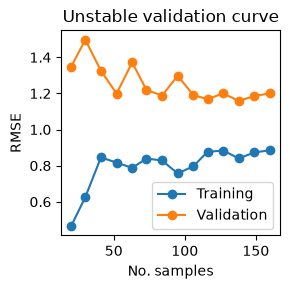

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

np.random.seed(42)

# -------------------------
# Synthetic dataset
# -------------------------
n_samples = 200
n_features = 20
n_latent = 6

Z = np.random.normal(size=(n_samples, n_latent))

loadings = np.random.normal(
    size=(n_latent, n_features)
)

X = (
    Z @ loadings
    + 0.5 * np.random.normal(
        size=(n_samples, n_features)
    )
)

true_effects = np.array([
    3.0, 2.0, 1.2,
    0.6, 0.0, 0.0
])

Y = (
    Z @ true_effects
    + 0.9 * np.random.normal(size=n_samples)
)

# Fixed validation set
X_train, X_val, y_train, y_val = train_test_split(
    X,
    Y,
    test_size=40,
    random_state=42
)

# -------------------------
# Learning curve
# -------------------------
n_components = 6

sample_sizes = np.linspace(
    20,
    len(X_train),
    14,
    dtype=int
)

train_rmse = []
validation_rmse = []

for i, n in enumerate(sample_sizes):

    # Use increasingly more training data
    # but randomize which observations are added
    rng = np.random.RandomState(100 + i)

    indices = rng.choice(
        len(X_train),
        size=n,
        replace=False
    )

    X_sub = X_train[indices]
    y_sub = y_train[indices]

    model = PLSRegression(
        n_components=n_components
    )

    model.fit(X_sub, y_sub)

    y_train_pred = model.predict(X_sub).ravel()
    y_val_pred = model.predict(X_val).ravel()

    train_rmse.append(
        np.sqrt(
            mean_squared_error(
                y_sub,
                y_train_pred
            )
        )
    )

    validation_rmse.append(
        np.sqrt(
            mean_squared_error(
                y_val,
                y_val_pred
            )
        )
    )

# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(3, 3))

plt.plot(
    sample_sizes,
    train_rmse,
    marker="o",
    label="Training"
)

plt.plot(
    sample_sizes,
    validation_rmse,
    marker="o",
    label="Validation"
)

plt.xlabel("No. samples")
plt.ylabel("RMSE")
plt.title("Unstable validation curve")

plt.legend()
plt.tight_layout()
plt.show()